# When Does the Rice Wake Up?

**Per-pixel phenology rasters of the Isla Mayor paddies, Guadalquivir marshes**

The [time series notebook](03_time_series_analysis.ipynb) asks when a season starts at
**one point**: it downloads the series with `getInfo` and fits the curve on the client with
SciPy. That is the right tool for a field you can name, and the wrong one for a question
like *does the season start earlier on one side of the marsh than the other* — which needs
an answer per pixel, not per point.

`SpatialPhenologyAnalyzer` computes the same family of metrics **entirely server-side**, and
returns them as Earth Engine images: one band per metric, values in day of year.

| Band | Meaning |
|---|---|
| `sos`, `pos`, `eos` | Start, peak and end of season, as day of year |
| `los` | Length of season, `eos - sos`, in days |
| `amplitude`, `peak_value`, `baseline` | How high the curve rises, its maximum, its floor |
| `growth_rate`, `senescence_rate` | How fast it greens up and how fast it senesces |

Rice is a good place to ask the question. The cycle is unusually sharp and it is
*imposed*, not weather-driven: the paddies are flooded and sown in spring, reach full canopy
in high summer and are drained and harvested in autumn. A pixel of rice should therefore
show a tall, narrow curve, and neighbouring pixels should agree — unless the farm calendar
differs, which is exactly what a per-pixel map can reveal and a single point cannot.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, SpatialPhenologyAnalyzer

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


## 2. The paddies

A rectangle over the Isla Mayor rice, on the right bank of the Guadalquivir. It is small on
purpose: phenology is computed per pixel from twelve composites a year, so the cost grows
with the area, and a tight ROI keeps every cell below the five-minute interactive limit.

To run it over your own area, draw it on a `geemap` map and pass
`roi = Map.draw_last_feature.geometry()` — with `.geometry()`, because `reduceRegion` does
not accept a `Feature`.

ROI: 138 km²


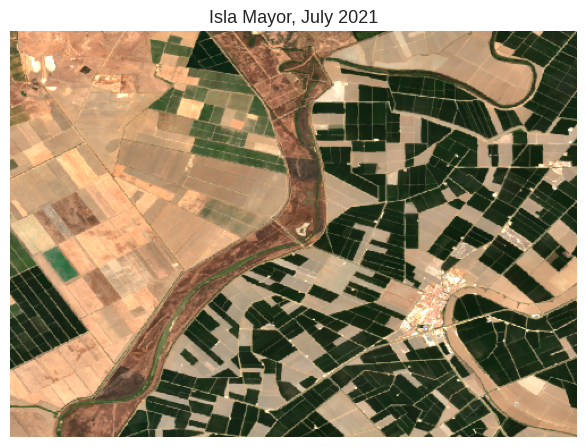

In [2]:
roi = ee.Geometry.Rectangle([-6.27, 37.10, -6.13, 37.20])

print(f'ROI: {roi.area(100).divide(1e6).getInfo():.0f} km²')


def thumbnail(image, vis, region=None, dimensions=500):
    # One static PNG of an image, so the book shows a map instead of an empty widget
    url = image.visualize(**vis).getThumbURL(
        {'region': region or roi, 'dimensions': dimensions, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))


# True colour in high summer, when the rice is at full canopy
summer = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi).filterDate('2021-07-01', '2021-08-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).median())

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(thumbnail(summer, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500}))
ax.set_title('Isla Mayor, July 2021')
ax.axis('off')
plt.tight_layout()

## 3. Twelve composites a year

Phenology needs enough points inside the year to see a curve, so the composites are
**monthly** (`periods=12`); with `periods=4` the class warns that the intra-annual
resolution is too coarse to place a start of season.

`key` picks the reducer inside each month. The median is the safe default; measured on this
ROI, swapping it for the 90th percentile or the maximum moves the median start of season by
about one day, so it is not a knob worth agonising over here. What the dates *are* sensitive
to is the method that reads them off the curve, which is section 5.

In [3]:
processor = NdviSeasonality(
    roi=roi,
    periods=12,           # monthly
    start_year=2019,
    end_year=2022,
    sat='S2',
    index='ndvi',
    key='median',
)

pheno = SpatialPhenologyAnalyzer(processor)

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


## 4. The typical season

`phenology_summary()` collapses every year into one image, taking the median of each metric
across years — the phenology the area *usually* has, with the odd year smoothed away.

Read the four maps together. `sos` and `eos` say when the season opens and closes, `pos`
when it peaks, and `los` how long it lasts. In a crop calendar the three dates should be
tight; where they are not, something else is growing.

bands: ['sos', 'pos', 'eos', 'los', 'amplitude', 'peak_value', 'baseline', 'growth_rate', 'senescence_rate']


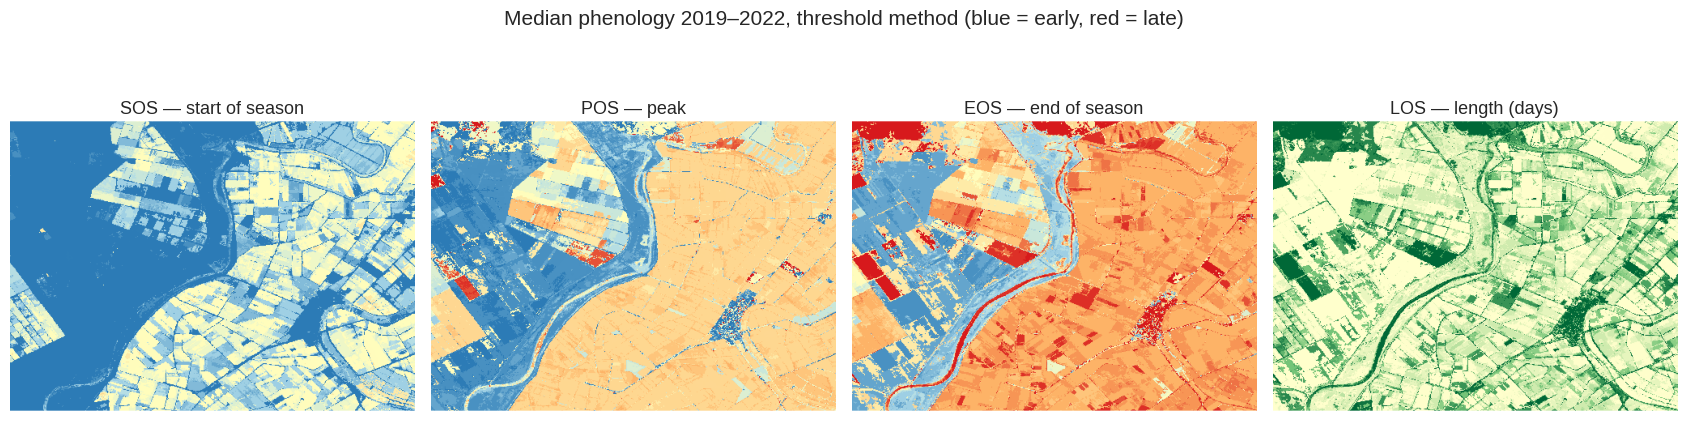

In [4]:
summary = pheno.phenology_summary(method='threshold', reducer='median')
print('bands:', summary.bandNames().getInfo())

doy_vis = {'min': 60, 'max': 330, 'palette': ['#2c7bb6', '#abd9e9', '#ffffbf',
                                              '#fdae61', '#d7191c']}
los_vis = {'min': 60, 'max': 240, 'palette': ['#ffffcc', '#78c679', '#006837']}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (band, vis, label) in zip(axes, [
        ('sos', doy_vis, 'SOS — start of season'),
        ('pos', doy_vis, 'POS — peak'),
        ('eos', doy_vis, 'EOS — end of season'),
        ('los', los_vis, 'LOS — length (days)')]):
    im = ax.imshow(thumbnail(summary.select(band), vis))
    ax.set_title(label)
    ax.axis('off')
fig.suptitle('Median phenology 2019–2022, threshold method (blue = early, red = late)',
             y=1.02)
plt.tight_layout()

### What the numbers say

The maps show the pattern; these are the values behind them. A coarse scale is deliberate:
`reduceRegion` at 10 m over the whole ROI is the classic way to hit *User memory limit
exceeded* in interactive mode, and for a summary statistic it buys nothing.

In [5]:
stats = summary.select(['sos', 'pos', 'eos', 'los', 'amplitude']).reduceRegion(
    reducer=ee.Reducer.median().combine(ee.Reducer.percentile([10, 90]), sharedInputs=True),
    geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

table = pd.DataFrame({
    'p10': {b: stats[f'{b}_p10'] for b in ['sos', 'pos', 'eos', 'los', 'amplitude']},
    'median': {b: stats[f'{b}_median'] for b in ['sos', 'pos', 'eos', 'los', 'amplitude']},
    'p90': {b: stats[f'{b}_p90'] for b in ['sos', 'pos', 'eos', 'los', 'amplitude']},
})
table.round(1)

,p10,median,p90
sos,16.0,106.5,197.1
pos,75.3,228.4,243.4
eos,90.3,258.3,289.3
los,46.0,76.5,211.5
amplitude,0.4,0.7,1.0


The median pixel starts its season on day **106**, peaks on day **228** and ends on day
**258** — 16 April, 16 August, 15 September. That is the rice calendar of the lower
Guadalquivir as an agronomist would write it: sowing into flooded paddies in April, full
canopy in high summer, drained and harvested in September. A method that returns the right
answer on a crop whose calendar is known is a method you can take somewhere it is not.

The spread is the part worth reading carefully. The 10th and 90th percentiles of SOS are 76
and 197 — a range of four months — and `los` runs from 46 to 211 days. That is not
measurement error. **The rectangle is not all rice.** It contains the Guadalquivir itself,
marsh, tracks, farm buildings and other crops, and a pixel of open water has no season at
all; asked for one anyway, it returns whatever the curve-fitting finds in what is mostly
noise. Section 7 uses `amplitude` to tell those pixels apart from the ones with a real
cycle, which is the honest way to summarise a raster over a mixed area.

## 5. Three methods, three definitions of "start"

The class offers three ways to place the dates, and they are not variations on one idea —
each answers a slightly different question:

| Method | Where it puts SOS | Where it shows its character |
|---|---|---|
| `threshold` | first day above a fraction of the seasonal amplitude | robust, but sensitive to the threshold |
| `derivative` | the day of steepest increase between composites | later in a fast-greening crop, because a paddy crosses the threshold long before it peaks in slope |
| `harmonic` | a Fourier curve is fitted per pixel, then the threshold is read off the smooth curve | tolerant of a missing month, since the fit interpolates it |

They should disagree. What matters is whether the disagreement is a matter of definition —
a few days either way, which is expected — or whether one of them is placing the season
somewhere the crop calendar says it cannot be.

In [6]:
methods = ['threshold', 'derivative', 'harmonic']
sos_maps = {m: pheno.phenology_summary(method=m).select('sos') for m in methods}

rows = {}
for m, image in sos_maps.items():
    rows[m] = image.reduceRegion(
        reducer=ee.Reducer.median().combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

pd.DataFrame({'median SOS (DOY)': {m: rows[m]['sos_median'] for m in methods},
              'spread (std, days)': {m: rows[m]['sos_stdDev'] for m in methods}}).round(1)

,median SOS (DOY),"spread (std, days)"
threshold,106.5,69.3
derivative,182.0,73.4
harmonic,56.0,58.8


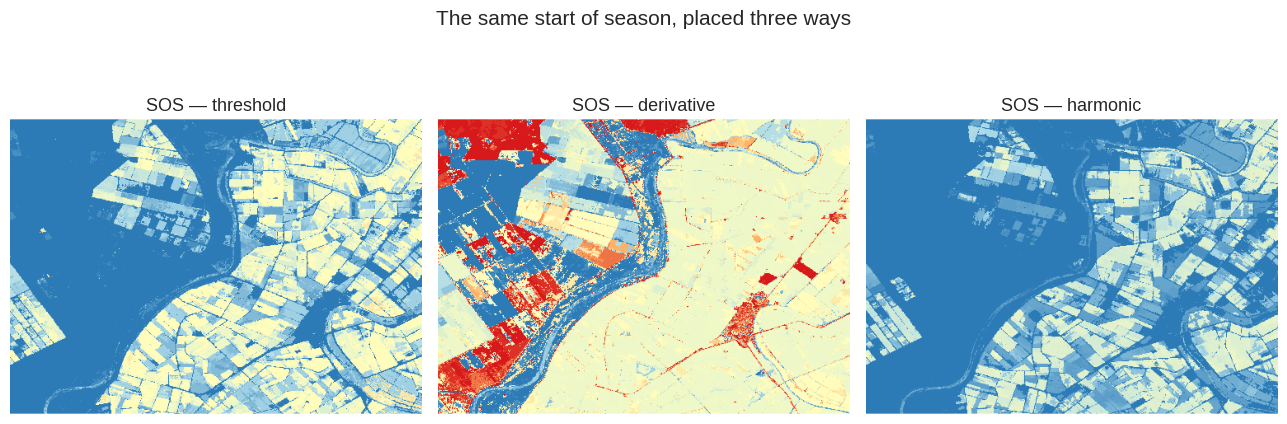

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, m in zip(axes, methods):
    ax.imshow(thumbnail(sos_maps[m], doy_vis))
    ax.set_title(f'SOS — {m}')
    ax.axis('off')
fig.suptitle('The same start of season, placed three ways', y=1.02)
plt.tight_layout()

Ninety-five days separate the earliest answer from the latest, for the same pixels and the
same data. But the two gaps are not the same kind of gap.

**`derivative` is late by definition, and that is fine.** It marks the day of steepest
increase, which in a transplanted crop arrives weeks after the first green shows: the
seedlings emerge slowly and then the canopy closes fast. Day 182 against day 106 is the
distance between "the paddy started to green" and "the paddy filled in". Both are defensible
answers to "when did the season start"; they are answers to slightly different questions.
Whichever you pick, use it consistently — the number only means something relative to its own
definition.

**`harmonic` at day 56 is a different matter.** It is not a stricter or looser reading of
the same curve; mid-February is before anything is planted. That is the one worth chasing,
and the next section does.

## 6. Why the harmonic fit is early, and how to fix it

The harmonic method puts the peak well before the other two, and it is not a rounding
difference. That is worth chasing rather than shrugging at, because the fix is a parameter
and the reason is the shape of the crop.

A Fourier fit with `n_harmonics=2` can represent one annual wave plus one correction to it.
That is a good model of natural vegetation, which greens and senesces smoothly. A rice paddy
is not that shape: it is a **narrow spike on a flat floor** — bare or flooded ground for
most of the year, then a fast rise to a closed canopy and an abrupt harvest. Two terms
cannot make a spike, so the fit spreads it into a broad hump, and the maximum of a broad
hump sits earlier than the maximum of the spike it is approximating.

Raising the number of harmonics gives the fit the terms it needs.

In [8]:
METRICS = ['sos', 'pos', 'eos', 'los']

harmonic_test = []
for n in [2, 3, 4]:
    image = pheno.phenology_summary(method='harmonic', n_harmonics=n)
    values = image.select(METRICS).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9,
        bestEffort=True, tileScale=4).getInfo()
    harmonic_test.append({'n_harmonics': n, **{m: values[m] for m in METRICS}})

harmonic_test = pd.DataFrame(harmonic_test).set_index('n_harmonics')

print(f"threshold method, for comparison: "
      f"SOS {rows['threshold']['sos_median']:.0f}, POS {table.loc['pos', 'median']:.0f}")
harmonic_test.round(0)

threshold method, for comparison: SOS 106, POS 228


,sos,pos,eos,los
n_harmonics,,,,
2,56.0,171.0,271.0,110.0
3,96.0,221.0,266.0,95.0
4,71.0,221.0,266.0,105.0


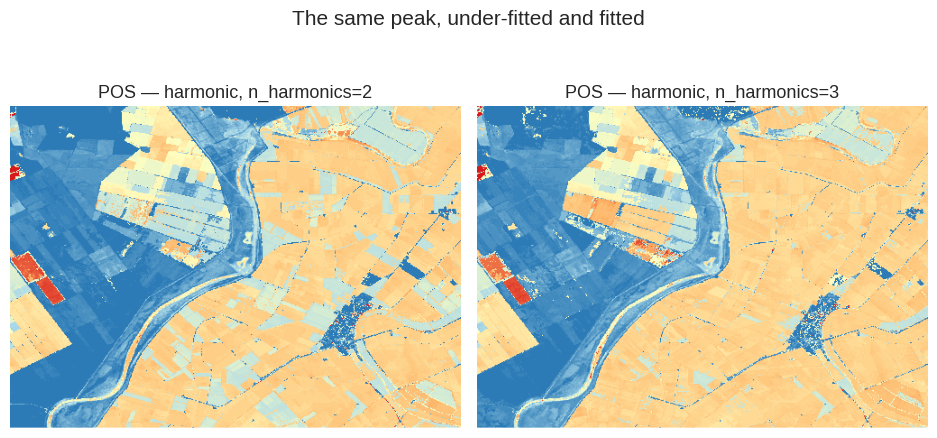

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
for ax, n in zip(axes, [2, 3]):
    ax.imshow(thumbnail(pheno.phenology_summary(method='harmonic',
                                                n_harmonics=n).select('pos'), doy_vis))
    ax.set_title(f'POS — harmonic, n_harmonics={n}')
    ax.axis('off')
fig.suptitle('The same peak, under-fitted and fitted', y=1.02)
plt.tight_layout()

Two harmonics put the peak on day **171**; three put it on day **221**, and the threshold
method — which does no fitting at all — says **228**. Adding one term to the Fourier series
moves the peak fifty days and lands it within a week of a completely independent method.

The default is not a bug, it is a default tuned for a different kind of vegetation. Natural
canopies green and senesce gradually, and two harmonics describe that shape well while
staying resistant to noise. A rice paddy is the opposite: flat for eight months, then a fast
rise and an abrupt harvest. Two terms cannot make that corner, so the fit turns the spike
into a wide hump — and the maximum of a wide hump sits earlier than the maximum of the spike
it is standing in for.

Going on to four harmonics moves the peak no further (still day 221) and unsettles SOS
instead, which is the usual sign of diminishing returns: the extra terms have stopped
describing the season and started describing the noise.

```{admonition} The practical rule
:class: tip
Raise `n_harmonics` when the cycle is sharp — irrigated crops, double cropping, anything with
a human calendar behind it — and leave it at 2 for natural vegetation. Either way, check the
peak against a date you already know before trusting the rest of the numbers. A phenology
raster is very willing to give you dates that are precise and wrong.
```

## 7. Year by year, and the years the rice did not happen

`extract_phenology_rasters()` returns one image per year instead of the aggregate, each
tagged with its `year`. This is the output to use when the question is about *change* —
and it is also where a per-pixel method stops being a formality, because a year can simply
not have a season.

4 images, one per year


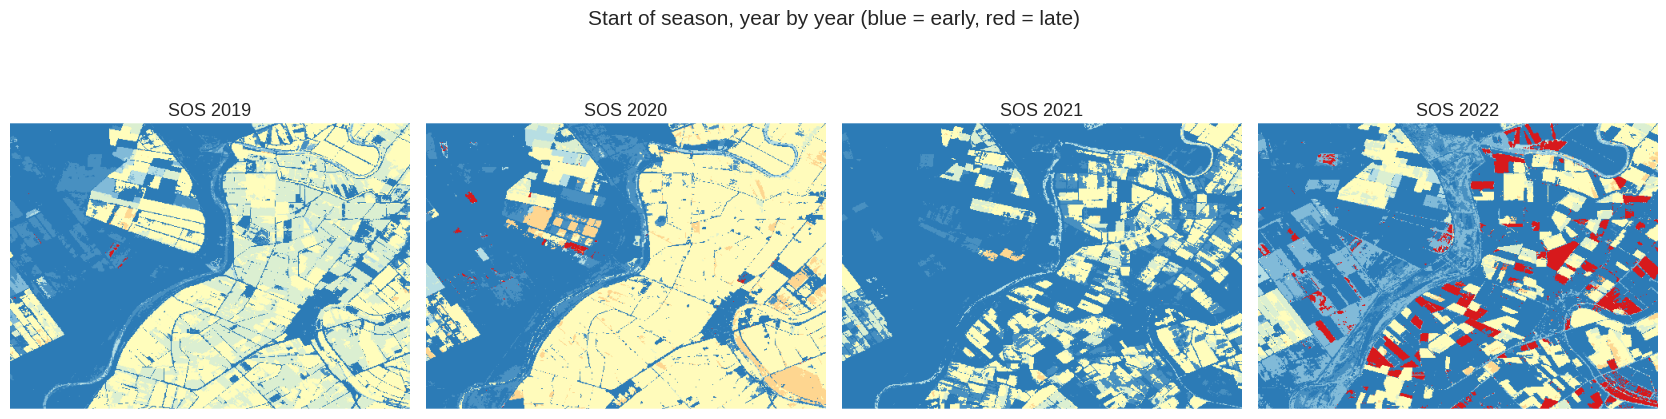

In [10]:
yearly = pheno.extract_phenology_rasters(method='threshold')
years = list(range(processor.start_year, processor.end_year + 1))
print(f'{yearly.size().getInfo()} images, one per year')

fig, axes = plt.subplots(1, len(years), figsize=(4.2 * len(years), 4.6))
for ax, year in zip(axes, years):
    image = ee.Image(yearly.filter(ee.Filter.eq('year', year)).first())
    ax.imshow(thumbnail(image.select('sos'), doy_vis))
    ax.set_title(f'SOS {year}')
    ax.axis('off')
fig.suptitle('Start of season, year by year (blue = early, red = late)', y=1.02)
plt.tight_layout()

In [11]:
AMPLITUDE = 0.3     # below this a pixel has no season worth dating

per_year = []
for year in years:
    image = ee.Image(yearly.filter(ee.Filter.eq('year', year)).first())
    seasonal = image.updateMask(image.select('amplitude').gte(AMPLITUDE))

    dates = seasonal.select(['sos', 'eos', 'los']).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9,
        bestEffort=True, tileScale=4).getInfo()
    # mask().mean() over the ROI is the fraction of pixels that survived the filter
    share = seasonal.select('sos').mask().reduceRegion(
        ee.Reducer.mean(), roi, scale=60, maxPixels=1e9,
        bestEffort=True, tileScale=4).getInfo()['sos']

    per_year.append({'year': year, **{k: dates[k] for k in ['sos', 'eos', 'los']},
                     'seasonal area': share})

per_year = pd.DataFrame(per_year).set_index('year')
per_year.round(2)

,sos,eos,los,seasonal area
year,,,,
2019,166.0,228.0,62.00,0.93
2020,198.0,290.0,92.00,0.94
2021,45.0,258.0,61.00,0.79
2022,105.0,258.0,60.78,0.56


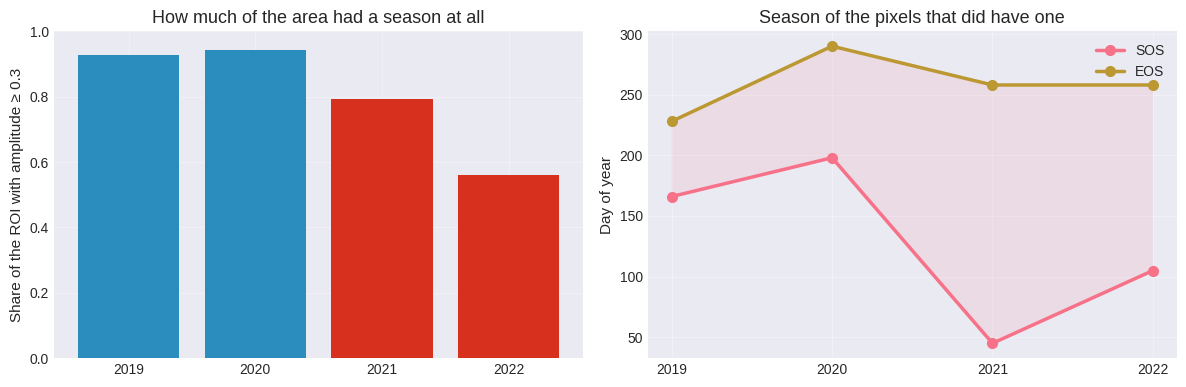

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(per_year.index.astype(str), per_year['seasonal area'],
            color=['#2b8cbe' if v > 0.8 else '#d7301f' for v in per_year['seasonal area']])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel(f'Share of the ROI with amplitude ≥ {AMPLITUDE}')
axes[0].set_title('How much of the area had a season at all')

axes[1].plot(per_year.index, per_year['sos'], 'o-', label='SOS')
axes[1].plot(per_year.index, per_year['eos'], 'o-', label='EOS')
axes[1].fill_between(per_year.index, per_year['sos'], per_year['eos'], alpha=0.12)
axes[1].set_ylabel('Day of year')
axes[1].set_xticks(per_year.index)
axes[1].set_title('Season of the pixels that did have one')
axes[1].legend(frameon=False)

for ax in axes:
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
plt.tight_layout()

Read the four maps from left to right and something happens that is not about phenology at
all. In 2019 and 2020 the whole plain carries a season — the pale field pattern covering
everything but the river. In 2021 much of it has turned blue. By 2022 the pale parcels are
scattered islands, and a crowd of red ones has appeared: sown very late.

The table puts a number on it. The share of the ROI with a real seasonal amplitude goes
**0.93, 0.94, 0.79, 0.56**. A third of the area stopped having a growing season.

This is not the method failing. **These are drought years, and planting rice in the marshes
was restricted**, so on much of the plain there was no crop to have a phenology. The dates
for 2021 and 2022 should be read as belonging only to the parcels that were planted — which
is exactly what the amplitude filter selects — and the collapse in seasonal area is the more
informative measurement of the two.

Two things follow for anyone using these rasters:

- **A flat year over irrigated land is a result, not an error.** Before blaming the
  algorithm, ask whether there was a crop. Here the answer came from knowing the area; if you
  do not know it, the seasonal-area series is the first thing to plot.
- **Blue in these maps means two different things.** The palette bottoms out at day 60, so a
  pixel that genuinely started early and a pixel with no season to start are painted the same
  colour. That is why the summary filters on `amplitude` rather than mapping the dates
  straight — and why an unfiltered median over a mixed area is worth very little.

```{note}
Which years carried restrictions, and how severe they were, is a matter for the basin
authority's records rather than for this notebook. The point here is the shape of the signal,
not the administrative history.
```

## 8. Taking the rasters out

Both entry points accept `export=True`, with two targets:

- `export_target='local'` downloads a GeoTIFF to the working directory. Band names are
  embedded with **rasterio** when it is installed, so QGIS shows `sos`, `pos`, `eos` instead
  of `Band 1, 2, 3`.
- `export_target='drive'` starts a batch task to Google Drive. Earth Engine preserves the
  band names natively and the memory budget is far larger, which is what you want for a big
  ROI or a fine scale.

The cells below are left unexecuted on purpose: running them would write files from a
documentation build.

In [13]:
# Local GeoTIFF, band names written by rasterio
# pheno.phenology_summary(method='harmonic', reducer='median',
#                         export=True, export_target='local', scale=20)

# Batch export to Drive, better for large areas
# pheno.phenology_summary(method='harmonic', reducer='median',
#                         export=True, export_target='drive',
#                         drive_folder='ndvi2gif_phenology', scale=20)

# One GeoTIFF per year
# pheno.extract_phenology_rasters(method='harmonic', export=True,
#                                 export_target='drive',
#                                 drive_folder='ndvi2gif_phenology', scale=20)

## 9. The knobs that matter

| Parameter | Default | What it changes |
|---|---|---|
| `threshold_percentile` | 50 | the fraction of the amplitude that defines the season |
| `adaptive_threshold` | True | lowers the threshold for SOS and raises it for EOS |
| `n_harmonics` | 2 | harmonics in the Fourier fit; more follows the curve closer and overfits sooner |
| `harmonic_step` | 10 | day step when rebuilding the smooth curve — finer is costlier |
| `min_observations` | 5 | valid composites a pixel needs in a year, or it is masked |
| `reducer` | `'median'` | how years are collapsed in `phenology_summary` |
| `scale`, `crs`, `drive_folder` | — | export geometry and destination |

And upstream, in `NdviSeasonality`: `periods` sets how many points the curve has, and `key`
which reducer builds each one. Those two decide more about the result than anything in the
table above.

## What to take away

**Per-pixel phenology sees the field boundaries.** The maps in section 4 are not a smooth
surface; they are parcels, each with its own sowing date, and the differences between
neighbouring fields are real and several weeks wide. That is the whole argument for the
raster over the point: no single station could have told you that, and an average over the
rectangle would have erased it.

**The method matters more than the composite.** Swapping the monthly reducer between median,
90th percentile and maximum moved the median start of season by about a day. Swapping the
method moved it by ninety-five. Spend the attention there.

**Check the peak against a calendar you know.** The harmonic fit with its default two
harmonics placed the peak fifty days early on this crop, and nothing in its output says so —
the rasters look perfectly plausible. One known date is all it takes to catch it, and raising
`n_harmonics` to 3 fixes it.

**Mask before you summarise.** Over a mixed area, the pixels with no season will happily
supply numbers, and those numbers will drag every regional statistic. `amplitude` is the
cheap filter, and the share of pixels that survive it is a useful measurement in its own
right — here it is what made the drought visible.

### See also

- [Point phenology and trends](03_time_series_analysis.ipynb) — the same metrics at a single
  point, with the curve-fitting done on the client, where you can see the actual series.